# Actividad 20 – Algoritmo de la Colonia de Hormigas (ACO)
**Derek Rodríguez**  
Procesamiento Inteligente de Datos  




## Descripción general - El Problema del Viajero (TSP)

El Problema del Viajante de Comercio (TSP) es uno de los problemas de optimización combinatoria más conocidos y estudiados en ciencias de la computación e investigación de operaciones.

### Enunciado
Dado un conjunto de n ciudades y las distancias entre cada par de ellas, encontrar la ruta más corta que:
- Parta de una ciudad de origen.
- Visite exactamente una vez cada ciudad.
- Regrese a la ciudad de origen.


## Objetivos, limitaciones y trabajos previos

### Objetivos
- Encontrar una ruta suficientemente buena (óptima o cercana al óptimo) en un tiempo de cómputo razonable.
- Aplicar metaheurísticas bio-inspiradas que imiten comportamientos naturales para explorar el espacio de soluciones.

### Limitaciones
- Los algoritmos exactos (programación dinámica, branch-and-bound) son impracticables para instancias grandes (n > 20–30).
- Los algoritmos aproximados no garantizan el óptimo global; la calidad de la solución depende de los parámetros y el número de iteraciones.
- El ACO puede converger prematuramente si los parámetros de evaporación de feromonas no están bien ajustados.

### Trabajos previos y enfoques

Tabla por Claude:

| Enfoque | Descripción | Limitación |
|---|---|---|
| **Fuerza bruta** | Evalúa todas las permutaciones | Solo viable para n muy pequeño |
| **Algoritmo voraz (Nearest Neighbor)** | Siempre elige la ciudad más cercana | Solución subóptima, sin mejora |
| **Algoritmos genéticos** | Evolución de poblaciones de rutas | Requiere buen diseño de operadores |
| **Simulated Annealing** | Acepta soluciones peores con cierta probabilidad | Sensible a la temperatura inicial |
| **Colonia de Hormigas (ACO)** | Feromonas guían la búsqueda colectiva | Requiere ajuste de α, β y evaporación |
| **Algoritmo de Lin-Kernighan** | Optimización local 2-opt / 3-opt | Óptimo local, no global |

El Algoritmo de la Colonia de Hormigas fue propuesto por Marco Dorigo en 1992 en su tesis doctoral. Se inspira en el comportamiento real de las hormigas: al buscar comida, depositan feromonas en los caminos que recorren; los caminos más cortos reciben más feromonas (porque las hormigas los recorren más veces), guiando a las demás hacia la mejor ruta

## 3. Código – Algoritmo de la Colonia de Hormigas

El código a continuación reproduce el **Código 45** del libro (pp. 237–240).

In [6]:
import random, sys, math

def matrizDistancias(nCiud, distanciaMaxima):
    matriz = [[0 for i in range(nCiud)] for j in range(nCiud)]

    for i in range(nCiud):
        for j in range(i):
            matriz[i][j] = distanciaMaxima * random.random()
            matriz[j][i] = matriz[i][j]

    return matriz

def eligeCiudad(dists, ferom, visitadas):
    listaPesos  = []
    disponibles = []
    actual      = visitadas[-1]
    alfa = 1.0
    beta = 0.5

    for i in range(len(dists)):
        if i not in visitadas:
            fer  = math.pow((1.0 + ferom[actual][i]), alfa)
            peso = math.pow(1.0 / dists[actual][i], beta) * fer
            disponibles.append(i)
            listaPesos.append(peso)

    valor      = random.random() * sum(listaPesos)
    acumulado  = 0.0
    i          = -1
    while valor > acumulado:
        i         += 1
        acumulado += listaPesos[i]

    return disponibles[i]


def eligeCamino(distancias, feromonas):
    camino     = [0]
    longCamino = 0

    while len(camino) < len(distancias):
        ciudad      = eligeCiudad(distancias, feromonas, camino)
        longCamino += distancias[camino[-1]][ciudad]
        camino.append(ciudad)

    longCamino += distancias[camino[-1]][0]
    camino.append(0)

    return (camino, longCamino)


def rastroFeromonas(feromonas, camino, dosis):
    for i in range(len(camino) - 1):
        feromonas[camino[i]][camino[i+1]] += dosis


def evaporaFeromonas(feromonas):
    for lista in feromonas:
        for i in range(len(lista)):
            lista[i] *= 0.9


def hormigas(distancias, iteraciones, distMedia):
    n         = len(distancias)
    feromonas = [[0 for i in range(n)] for j in range(n)]

    mejorCamino     = []
    longMejorCamino = sys.maxsize

    for iter in range(iteraciones):
        (camino, longCamino) = eligeCamino(distancias, feromonas)

        if longCamino <= longMejorCamino:
            mejorCamino     = camino
            longMejorCamino = longCamino

        rastroFeromonas(feromonas, camino, distMedia / longCamino)
        evaporaFeromonas(feromonas)

    return (mejorCamino, longMejorCamino)


print("Funciones del ACO cargadas correctamente.")

Funciones del ACO cargadas correctamente.



## 4. Prueba del algoritmo

Se generan los parámetros de prueba tal como indica el libro (pp. 239–240) y se ejecuta el algoritmo.

In [7]:
random.seed(42)

numCiudades     = 10
distanciaMaxima = 10
ciudades        = matrizDistancias(numCiudades, distanciaMaxima)

iteraciones = 1000
distMedia   = numCiudades * distanciaMaxima / 2

(camino, longCamino) = hormigas(ciudades, iteraciones, distMedia)

print("Camino: ", camino)
print("Longitud del camino: ", round(longCamino, 4))

Camino:  [0, 2, 5, 9, 8, 6, 7, 1, 4, 3, 0]
Longitud del camino:  13.3261



## 5. Visualización de la matriz de distancias y del camino encontrado

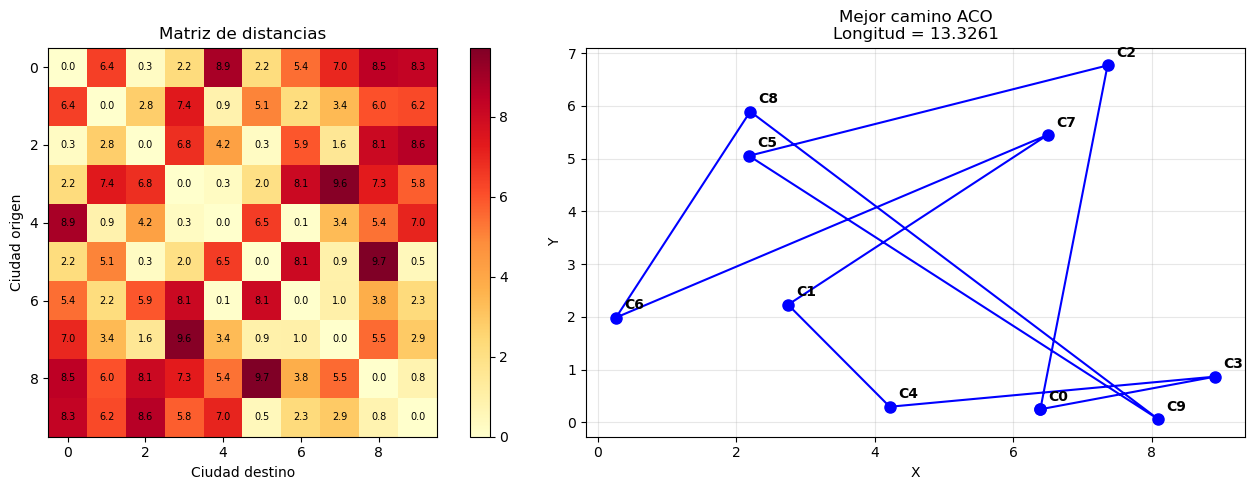

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# --- Heatmap de la matriz de distancias ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mat = np.array(ciudades)
im = axes[0].imshow(mat, cmap='YlOrRd')
axes[0].set_title('Matriz de distancias')
axes[0].set_xlabel('Ciudad destino')
axes[0].set_ylabel('Ciudad origen')
plt.colorbar(im, ax=axes[0])

# Anotar valores
for i in range(numCiudades):
    for j in range(numCiudades):
        axes[0].text(j, i, f"{mat[i,j]:.1f}", ha='center', va='center', fontsize=7)

# --- Visualización del camino sobre coordenadas aleatorias ---
random.seed(42)
coords = [(random.uniform(0,10), random.uniform(0,10)) for _ in range(numCiudades)]
xs = [coords[c][0] for c in camino]
ys = [coords[c][1] for c in camino]

axes[1].plot(xs, ys, 'b-o', markersize=8)
for idx, (x, y) in enumerate(coords):
    axes[1].annotate(f'C{idx}', (x, y), textcoords='offset points',
                     xytext=(6, 6), fontsize=10, fontweight='bold')
axes[1].set_title(f'Mejor camino ACO\nLongitud = {longCamino:.4f}')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Análisis de convergencia – Longitud del mejor camino por iteración

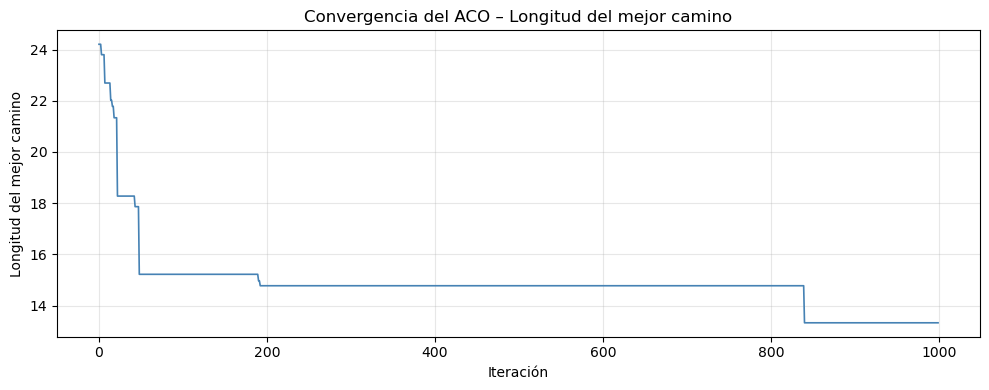

Mejor camino final: [0, 2, 5, 9, 8, 6, 7, 1, 4, 3, 0]
Longitud final:     13.3261


In [9]:
random.seed(42)
ciudades2 = matrizDistancias(numCiudades, distanciaMaxima)
n         = len(ciudades2)
feromonas = [[0 for i in range(n)] for j in range(n)]

mejorCamino     = []
longMejorCamino = sys.maxsize
historial       = []

distMedia2 = numCiudades * distanciaMaxima / 2

for it in range(iteraciones):
    (camino_it, long_it) = eligeCamino(ciudades2, feromonas)

    if long_it <= longMejorCamino:
        mejorCamino     = camino_it
        longMejorCamino = long_it

    rastroFeromonas(feromonas, camino_it, distMedia2 / long_it)
    evaporaFeromonas(feromonas)
    historial.append(longMejorCamino)

plt.figure(figsize=(10, 4))
plt.plot(historial, color='steelblue', linewidth=1.2)
plt.title('Convergencia del ACO – Longitud del mejor camino')
plt.xlabel('Iteración')
plt.ylabel('Longitud del mejor camino')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mejor camino final: {mejorCamino}")
print(f"Longitud final:     {round(longMejorCamino, 4)}")


## 7. Conclusiones

1. **El TSP es NP-difícil**: con 10 ciudades existen 181,440 rutas posibles; el ACO encuentra una buena solución explorando solo 1,000 rutas.

2. **Mecanismo clave**: el depósito y la evaporación de feromonas crean un balance entre exploración (descubrir nuevas rutas) y explotación (reforzar las mejores conocidas).

3. **Parámetros importantes**:
   - `alfa = 1.0` → importancia de las feromonas.
   - `beta = 0.5` → importancia de la distancia (inversamente).
   - Tasa de evaporación `0.9` → las feromonas se reducen al 90% cada iteración.

4. **Convergencia**: la gráfica muestra cómo la longitud del mejor camino disminuye rápidamente en las primeras iteraciones y se estabiliza, lo cual es el comportamiento esperado de una metaheurística bien parametrizada.

5. **Limitación**: el resultado varía con la semilla aleatoria. Para producción se recomienda ejecutar múltiples instancias y tomar el mejor resultado global.